# MedBoard — Train GeoSample U-Net Segmentation Model

**Run this notebook in Google Colab to train the GeoSample U-Net.**

GeoSample replaces standard 3×3 convolutions and MaxPooling with:
- **Geometry-guided oriented sampling** — probes aligned to tumor boundaries
- **Differential tokens** — explicit gradient and curvature cues
- **Edge-preserving downsampling** — dual-path pooling that retains boundary signals
- **Consensus skip connections** — geometric alignment between encoder and decoder

What this notebook does:
1. Set up the environment (mount Drive, clone repo, copy data)
2. Load BRISC 2025 segmentation dataset
3. Build the GeoSample U-Net
4. Train with Dice+BCE loss and early stopping
5. Save best weights to Google Drive
6. Plot training curves
7. Evaluate on test set (Dice + IoU + per-sample breakdown)
8. Visualize predictions

**Expected training time:** ~15–25 minutes on Colab T4 GPU

## Cell 1 — Environment Setup (Run Every Session)

In [ ]:
import shutil, os, sys

# ── Detect environment ───────────────────────────────────────────────
try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

print(f'Running in: {"Google Colab" if IS_COLAB else "Local (VS Code)"}')

if IS_COLAB:
    from google.colab import drive

    # Mount Google Drive
    drive.mount('/content/drive')

    # Clone or update the MedBoard repo from GitHub
    if not os.path.exists('/content/MedBoard'):
        !git clone https://github.com/shivanshu0055/Medical-Image.git /content/MedBoard
    else:
        !git -C /content/MedBoard pull

    # Copy dataset from Drive to local SSD (faster I/O during training)
    if not os.path.exists('/content/data'):
        print('Copying dataset to local SSD (~30 sec)...')
        shutil.copytree('/content/drive/MyDrive/medboard/data/brisc2025', '/content/data')
        print('Done.')
    else:
        print('Dataset already on local SSD.')

    # Install dependencies
    !pip install -q -r /content/MedBoard/requirements_colab.txt

    # Set Python path so we can import from MedBoard
    sys.path.insert(0, '/content/MedBoard')

    # Colab paths
    DATA_ROOT   = '/content/data'
    WEIGHTS_DIR = '/content/drive/MyDrive/medboard/weights'
    CONFIG_PATH = '/content/MedBoard/configs/config.yaml'

else:
    # ── Local / VS Code paths ────────────────────────────────────────
    REPO_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..'))
    DATA_ROOT   = os.path.join(REPO_ROOT, 'data', 'raw')
    WEIGHTS_DIR = os.path.join(REPO_ROOT, 'weights')
    CONFIG_PATH = os.path.join(REPO_ROOT, 'configs', 'config.yaml')

    if REPO_ROOT not in sys.path:
        sys.path.insert(0, REPO_ROOT)

# ── Shared paths ─────────────────────────────────────────────────────
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, 'geosample_unet_best.pth')
FINAL_PATH      = os.path.join(WEIGHTS_DIR, 'geosample_unet_brisc.pth')
os.makedirs(WEIGHTS_DIR, exist_ok=True)

print(f'\nSetup complete!')
print(f'  Data       → {DATA_ROOT}')
print(f'  Weights    → {WEIGHTS_DIR}')
print(f'  Checkpoint → {CHECKPOINT_PATH}')

Running in: Google Colab
Mounted at /content/drive
Cloning into '/content/MedBoard'...
remote: Enumerating objects: 164, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 164 (delta 70), reused 132 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (164/164), 971.24 KiB | 3.03 MiB/s, done.
Resolving deltas: 100% (70/70), done.
Copying dataset to local SSD (~30 sec)...
Done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 118.1 MB/s eta 0

## Cell 2 — Verify GPU

In [ ]:
import torch

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM: {vram_gb:.1f} GB')
    if vram_gb >= 15:
        print('T4 detected — using optimized hyperparameters (batch=16, FP16).')
    else:
        print('Non-T4 GPU — consider reducing batch size if OOM occurs.')
else:
    print('WARNING: No GPU detected! Training will be very slow on CPU.')
    print('Go to Runtime → Change runtime type → T4 GPU')

PyTorch version: 2.11.0+cu128
CUDA available:  True
GPU: Tesla T4
VRAM: 14.6 GB
Non-T4 GPU — consider reducing batch size if OOM occurs.


## Cell 3 — Load Dataset

In [ ]:
from modules.seg_dataset import get_seg_dataloaders

# Hyperparameters tuned for Colab T4 (16 GB VRAM)
BATCH_SIZE  = 8   # T4 can handle 16 at 256x256 with FP16 (~5 GB)
NUM_WORKERS = 2    # Colab has 2 CPU cores

train_loader, val_loader, test_loader = get_seg_dataloaders(
    train_images_dir = f'{DATA_ROOT}/segmentation_task/train/images',
    train_masks_dir  = f'{DATA_ROOT}/segmentation_task/train/masks',
    test_images_dir  = f'{DATA_ROOT}/segmentation_task/test/images',
    test_masks_dir   = f'{DATA_ROOT}/segmentation_task/test/masks',
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    val_split   = 0.1,
    config_path = CONFIG_PATH,
)

[SegmentationDataset] train: 3933 image-mask pairs loaded | augmentation=ON
[SegmentationDataset] val: 3933 image-mask pairs loaded | augmentation=OFF
[SegmentationDataset] test: 860 image-mask pairs loaded | augmentation=OFF
DataLoaders ready:
  Train : 3540 samples → 443 batches
  Val   :  393 samples →  50 batches
  Test  :  860 samples → 108 batches


## Cell 4 — Build GeoSample U-Net

In [ ]:
import yaml
from modules.geosample_unet import build_geosample_unet, count_parameters

# Load config
print(f'Loading config from: {CONFIG_PATH}')
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# Build GeoSample U-Net
model = build_geosample_unet(cfg['segmentation'])
n_params = count_parameters(model)
print(f'GeoSample U-Net parameters: {n_params:,}  ({n_params/1e6:.2f}M)')

# Quick shape check
dummy = torch.randn(1, 3, 256, 256)
with torch.no_grad():
    out = model(dummy)
print(f'\nInput:  {tuple(dummy.shape)}')
print(f'Output: {tuple(out.shape)}  (expected: (1, 1, 256, 256))')
assert out.shape == (1, 1, 256, 256), 'Shape mismatch!'
print('Shape check passed.')

Loading config from: /content/MedBoard/configs/config.yaml
GeoSample U-Net parameters: 2,501,545  (2.50M)

Input:  (1, 3, 256, 256)
Output: (1, 1, 256, 256)  (expected: (1, 1, 256, 256))
Shape check passed.


## Cell 5 — Train

In [ ]:
from modules.seg_trainer import train_segmentation

history = train_segmentation(
    model           = model,
    train_loader    = train_loader,
    val_loader      = val_loader,
    epochs          = 40,       # max epochs (early stopping usually triggers ~20-25)
    learning_rate   = 1e-4,     # Adam with weight_decay=1e-5
    patience        = 7,        # stop if val loss doesn't improve for 7 epochs
    checkpoint_path = CHECKPOINT_PATH,
    device_str      = 'cuda',
)

Training on: cuda
GPU: Tesla T4
VRAM: 14.6 GB

Starting training: 40 max epochs, patience=7

Epoch 01/40


/content/MedBoard/modules/seg_trainer.py:350: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/content/MedBoard/modules/seg_trainer.py:233: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


    Batch [ 50/443]  loss=0.7684  dice=0.2104
    Batch [100/443]  loss=0.7277  dice=0.3227
    Batch [150/443]  loss=0.6902  dice=0.4137
    Batch [200/443]  loss=0.6497  dice=0.5727
    Batch [250/443]  loss=0.6286  dice=0.6486
    Batch [300/443]  loss=0.6262  dice=0.5677
    Batch [350/443]  loss=0.5930  dice=0.5642
    Batch [400/443]  loss=0.6230  dice=0.3918


/content/MedBoard/modules/seg_trainer.py:284: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Train → loss: 0.6799 | dice: 0.3885
  Val   → loss: 0.6023   | dice: 0.5241   [241s]

Epoch 02/40
    Batch [ 50/443]  loss=0.5655  dice=0.6013
    Batch [100/443]  loss=0.5208  dice=0.7867
    Batch [150/443]  loss=0.5359  dice=0.6763
    Batch [200/443]  loss=0.5487  dice=0.4472
    Batch [250/443]  loss=0.5294  dice=0.7190
    Batch [300/443]  loss=0.5497  dice=0.4837
    Batch [350/443]  loss=0.5137  dice=0.6231
    Batch [400/443]  loss=0.4601  dice=0.6627
  Train → loss: 0.5378 | dice: 0.5848
  Val   → loss: 0.4918   | dice: 0.6491   [239s]

Epoch 03/40
    Batch [ 50/443]  loss=0.4811  dice=0.5741
    Batch [100/443]  loss=0.4434  dice=0.6043
    Batch [150/443]  loss=0.4419  dice=0.6141
    Batch [200/443]  loss=0.4623  dice=0.6677
    Batch [250/443]  loss=0.4566  dice=0.6915
    Batch [300/443]  loss=0.4479  dice=0.5197
    Batch [350/443]  loss=0.4648  dice=0.5909
    Batch [400/443]  loss=0.4151  dice=0.6848
  Train → loss: 0.4362 | dice: 0.6570
  Val   → loss: 0.3882   |

## Cell 6 — Save Final Weights to Drive

In [ ]:
import shutil

# Copy best checkpoint to final weights path
shutil.copy(CHECKPOINT_PATH, FINAL_PATH)
print(f'Final weights saved to: {FINAL_PATH}')
print(f'Best val dice: {max(history["val_dice"]):.4f}  ({max(history["val_dice"])*100:.2f}%)')

Final weights saved to: /content/drive/MyDrive/medboard/weights/geosample_unet_brisc.pth
Best val dice: 0.8550  (85.50%)


## Cell 7 — Plot Training Curves

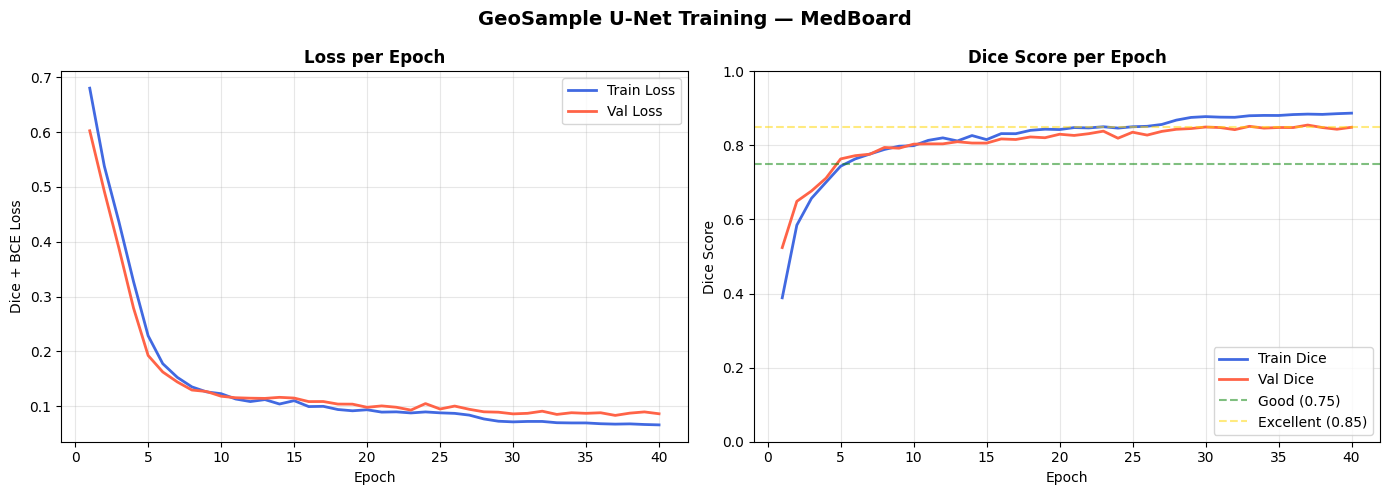

Plot saved to /content/drive/MyDrive/medboard/weights/geosample_training_curves.png


In [ ]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss curve ───────────────────────────────────────────────────────
ax1.plot(epochs_ran, history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
ax1.set_title('Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Dice + BCE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Dice score curve ─────────────────────────────────────────────────
ax2.plot(epochs_ran, history['train_dice'], label='Train Dice', color='royalblue', linewidth=2)
ax2.plot(epochs_ran, history['val_dice'],   label='Val Dice',   color='tomato',    linewidth=2)
ax2.axhline(0.75, color='green', linestyle='--', alpha=0.5, label='Good (0.75)')
ax2.axhline(0.85, color='gold',  linestyle='--', alpha=0.5, label='Excellent (0.85)')
ax2.set_title('Dice Score per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.set_ylim([0, 1])
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.suptitle('GeoSample U-Net Training — MedBoard', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save plot
plot_path = f'{WEIGHTS_DIR}/geosample_training_curves.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {plot_path}')

## Cell 8 — Evaluate on Test Set (Dice + IoU)

In [ ]:
from modules.seg_trainer import validate_one_epoch, DiceBCELoss
from torch.cuda.amp import autocast
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# ── Overall Test Loss & Dice ─────────────────────────────────────────
criterion = DiceBCELoss()
test_loss, test_dice = validate_one_epoch(model, test_loader, criterion, device)

print('=' * 65)
print('          GeoSample U-Net — Test Set Evaluation')
print('=' * 65)
print(f'  Test Loss (Dice+BCE):  {test_loss:.4f}')
print(f'  Test Dice Score:       {test_dice:.4f}  ({test_dice*100:.2f}%)')
print('-' * 65)

          GeoSample U-Net — Test Set Evaluation
  Test Loss (Dice+BCE):  0.0866
  Test Dice Score:       0.8540  (85.40%)
-----------------------------------------------------------------
